# SR3 — 확산 모델로 초해상

앞의 일곱 모델은 저해상도를 넣으면 고해상도가 한 번에 나온다. SR3 는 다르다.
**순전한 잡음에서 시작해 조금씩 걷어내며** 그림을 만든다. 저해상도 영상은 "이렇게 생긴
것을 만들라" 는 조건으로 매 스텝 들어간다.

```
잡음  →  조금 걷어냄  →  조금 더  →  …  →  결과
          ↑ 매 스텝 저해상도 영상을 조건으로 본다
```

결과는 미리 뽑아 저장소에 올려둔 것을 불러온다. **GPU 가 필요 없다.**

## 1. 준비

In [1]:
import sys, json, urllib.request

BASE = 'https://raw.githubusercontent.com/BWMIN-Hub/SR_practice/main'
urllib.request.urlretrieve(f'{BASE}/lib/sr_utils.py', 'sr_utils.py')
sys.modules.pop('sr_utils', None)
from sr_utils import *
import pandas as pd

RES = f'{BASE}/results/sr3'
V = 's1'          # 내려받은 파일 캐시 폴더
META = json.load(open(fetch(f'{RES}/meta.json', f'{V}/meta.json')))
PATCHES = list(META['patches'])
CENTER, SIZE = (67, 370), 90       # 다른 페이지와 같은 확대 자리


def load(name):
    return imageio.imread(fetch(f'{RES}/{name}.png', f'{V}/{name}.png'))


print(f"체크포인트 {META['ckpt']}   되돌리는 스텝 {META['steps']}   색보정 {META['mode']}")
print('패치:', ', '.join(PATCHES))

체크포인트 I20100_E100   되돌리는 스텝 100   색보정 low
패치: AOI_Paris_1_6_y0064_x0192, AOI_Seoul_14_y0256_x0128


## 2. 잡음에서 그림이 나오는 과정

되돌리기를 시작할 때는 **순전한 잡음**이다. 스텝을 밟을수록 저해상도 영상이 조건으로
끌어당겨 형태가 잡힌다. 아래는 그 과정을 몇 지점에서 잘라 본 것이다.

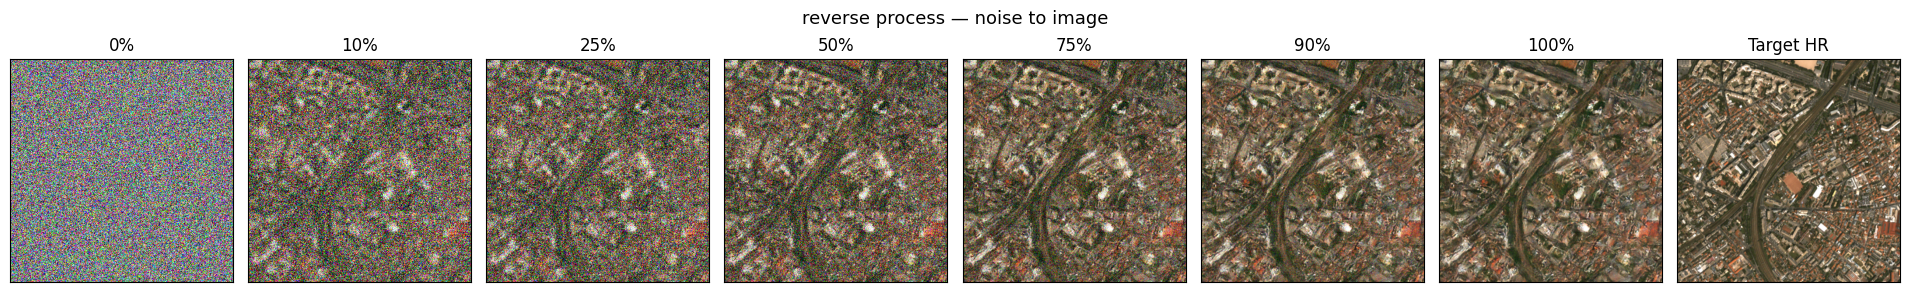

In [2]:
stem = PATCHES[0]
keep = META['keep']
fig, ax = plt.subplots(1, len(keep) + 1, figsize=(2.4 * (len(keep) + 1), 3.0))
for j, p in enumerate(keep):
    ax[j].imshow(imageio.imread(fetch(f'{RES}/steps/{stem}_t{p:03d}.png',
                                      f'{V}/steps/{stem}_t{p:03d}.png')))
    ax[j].set_title(f'{p}%', fontsize=12)
ax[-1].imshow(load(f'{stem}_HR')); ax[-1].set_title('Target HR', fontsize=12)
for a in ax:
    a.set_xticks([]); a.set_yticks([])
plt.suptitle('reverse process — noise to image', fontsize=13)
plt.tight_layout(); plt.show()

**0% 는 완전한 잡음이다.** 25% 쯤에서 큰 덩어리가 잡히고, 50% 를 넘으면 도로와 블록이
보이기 시작한다. 마지막까지 가도 정답만큼 또렷해지지는 않는데, 학습이 모자란 탓이다.

### 정리

**확산 모델은 만드는 방식이 다르다.** 한 번에 답을 내지 않고 잡음에서 시작해 여러 번
되돌린다. 그래서 추론이 느리고(400 스텝에 43초), 학습 뒤에도 스텝 수·일정·색보정 같은
선택지가 남는다.